## Vision-Language Chat
## Model : Qwen3.5-9B 

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
print(f"사용 가능한 GPU 수: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    reserved = torch.cuda.memory_reserved(i) / 1024**3
    # print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  |  전체: {total:.1f}GB  |  예약: {reserved:.1f}GB")

# CUDA_VISIBLE_DEVICES="1" 설정 시, 프로세스 내부에서 GPU는 cuda:0으로 리매핑됨
DEVICE = "cuda:0"
# print(f"\n사용 디바이스: {DEVICE}")

PyTorch 버전: 2.9.1+cu128
CUDA 사용 가능: True
사용 가능한 GPU 수: 1


In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "Qwen/Qwen3.5-9B"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map=DEVICE,
)
model.eval()
print("모델 로드 완료")

/home/yanghoon/miniconda3/envs/test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 4 files: 100%|██████████| 4/4 [02:44<00:00, 41.01s/it] 
The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 760/760 [00:03<00:00, 236.60it/s]


모델 로드 완료


발견된 이미지 파일: ['desk.jpeg', 'xai506_example_image.jpg']

[desk.jpeg]
원본 크기: 4000 x 3000
리사이즈 후: 1024 x 768

[xai506_example_image.jpg]
원본 크기: 4032 x 3024
리사이즈 후: 1024 x 768


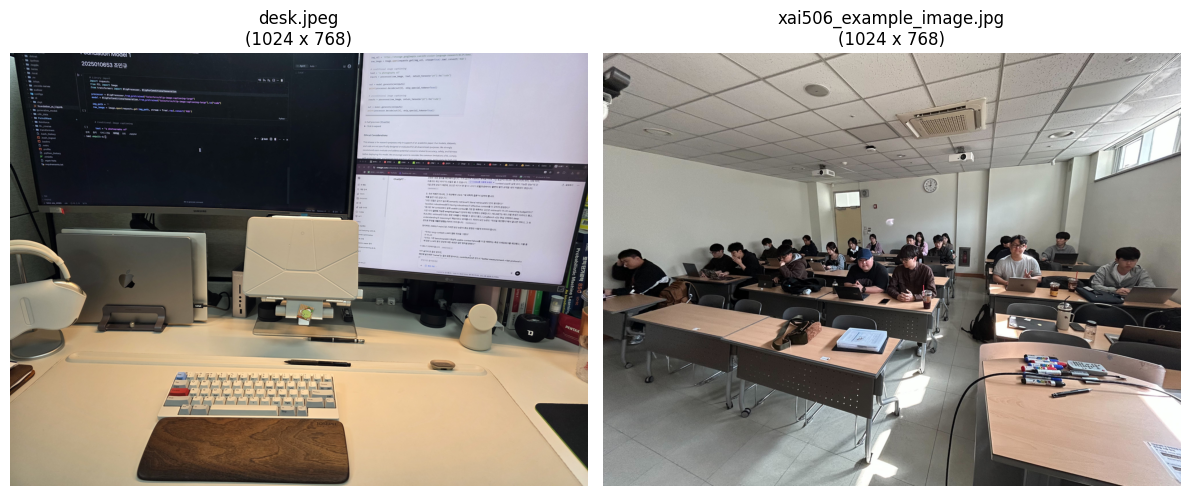

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

IMG_DIR = "/home/yanghoon/workspace/project/deeplearning/mk/img"
MAX_SIZE = 1024

def load_and_resize(img_path: str) -> Image.Image:
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    print(f"원본 크기: {w} x {h}")
    if w > MAX_SIZE or h > MAX_SIZE:
        ratio = min(MAX_SIZE / w, MAX_SIZE / h)
        new_w, new_h = int(w * ratio), int(h * ratio)
        image = image.resize((new_w, new_h), Image.LANCZOS)
        print(f"리사이즈 후: {new_w} x {new_h}")
    else:
        print("리사이즈 불필요")
    return image

# img 디렉토리 내 이미지 파일 목록
img_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])
print(f"발견된 이미지 파일: {img_files}")

# 이미지 로드 및 미리보기
images = {}
fig, axes = plt.subplots(1, len(img_files), figsize=(6 * len(img_files), 5))
if len(img_files) == 1:
    axes = [axes]

for ax, fname in zip(axes, img_files):
    path = os.path.join(IMG_DIR, fname)
    print(f"\n[{fname}]")
    img = load_and_resize(path)
    images[fname] = img
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{fname}\n({img.width} x {img.height})")

plt.tight_layout()
plt.show()

In [4]:
def vl_chat(image: Image.Image, question: str, max_new_tokens: int = 256) -> str:
    """단일 이미지 + 텍스트 질문을 받아 모델 응답을 반환합니다."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": question},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens)

    prompt_len = inputs["input_ids"].shape[-1]
    answer = processor.decode(outputs[0][prompt_len:], skip_special_tokens=True)
    return answer.strip()

### 단일 이미지 질의

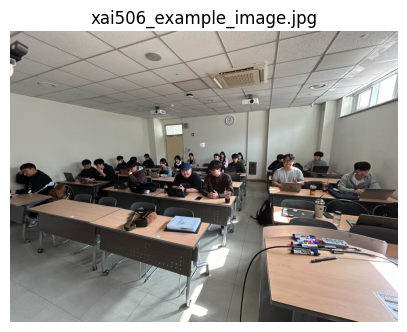

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Q: Describe this image in detail.
A: The user wants a detailed description of the provided image.

1.  **Overall Scene:** It's a classroom or lecture hall setting. There are rows of desks and chairs. Several students are seated, mostly facing forward or towards their laptops. The lighting is bright, likely a mix of overhead fluorescent lights and natural light coming from windows on the right.

2.  **Foreground:**
    *   **Bottom Left:** Empty desks. Two light wood-topped desks with grey metal frames. One has a brown bag and a notebook on it.
    *   **Bottom Right:** A large desk (likely the instructor's or front desk). It has various items on it: markers (blue, red, black), a calculator, a pen, and a black cable running across it.
    *   **Floor:** Tiled floor, light grey.

3.  **Mid-Ground (Students):**
    *   **Left Side:** A row of students.
        *   Front left: A young man in a black jacket with white stripes on the sleeves, looking down/sleeping.
        *   Next to him: A

In [5]:
# 사용할 이미지와 질문 설정
TARGET_IMAGE = "xai506_example_image.jpg"   
QUESTION     = "Describe this image in detail."

selected_image = images[TARGET_IMAGE]

# 이미지 미리보기
plt.figure(figsize=(5, 4))
plt.imshow(selected_image)
plt.axis("off")
plt.title(TARGET_IMAGE)
plt.show()

print(f"Q: {QUESTION}")
answer = vl_chat(selected_image, QUESTION)
print(f"A: {answer}")

### 전체 이미지 순회 질의

In [6]:
BATCH_QUESTION = "What do you see in this image? Describe it in detail."

for fname, img in images.items():
    print("=" * 60)
    print(f"이미지: {fname}  ({img.width} x {img.height})")
    print(f"Q: {BATCH_QUESTION}")
    answer = vl_chat(img, BATCH_QUESTION)
    print(f"A: {answer}")
    print()

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


이미지: desk.jpeg  (1024 x 768)
Q: What do you see in this image? Describe it in detail.


Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


A: The user wants a detailed description of the provided image.

1.  **Overall Scene:** It's a desk setup, likely a programmer's or developer's workspace. There are multiple monitors, a keyboard, a mouse, and various accessories. The lighting is bright, suggesting daytime or strong overhead lighting.

2.  **Monitors:**
    *   **Left Monitor:** A large, dark-themed screen. It shows code. The title bar says "Foundation Model 1". The code looks like Python, specifically using libraries like `torch` or similar ML frameworks. There are comments in Korean.
    *   **Right Monitor:** This is actually a dual-monitor setup on the right side, or perhaps a very wide monitor with multiple windows. Wait, looking closer, it's two distinct screens stacked or side-by-side? No, looking at the bezels, it looks like one large monitor on the right displaying multiple windows.
        *   **Top Right Window:** Shows code, similar to the left one but lighter theme (white background). It has Python code.
  

### 인터랙티브 채팅 (특정 이미지 고정 후 질문 반복)

In [ ]:
CHAT_IMAGE = "desk.jpeg"   # 채팅할 이미지 선택
chat_img   = images[CHAT_IMAGE]

print(f"[{CHAT_IMAGE}] 이미지에 대해 질문하세요. 종료하려면 'q' 또는 'quit' 입력\n")
plt.figure(figsize=(5, 4))
plt.imshow(chat_img)
plt.axis("off")
plt.title(CHAT_IMAGE)
plt.show()

while True:
    question = input("Q: ").strip()
    if question.lower() in ("q", "quit", "exit", ""):
        print("채팅을 종료합니다.")
        break
    answer = vl_chat(chat_img, question)
    print(f"A: {answer}\n")